<a href="https://colab.research.google.com/github/KaterinaSor2005/homework_Sorokina332/blob/main/%D0%9F%D1%80%D0%BE%D0%B5%D0%BA%D1%82%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Про датасет

https://www.kaggle.com/datasets/iabhishekofficial/mobile-price-classification

Датасет содержит 2000 записей о характеристиках мобильных телефонов.

Целевая переменная price_range — ценовая категория (0 = низкая, 1 = средняя, 2 = высокая, 3 = очень высокая).

# Постановка задачи

Целью работы является построение модели машинного обучения, которая по характеристикам смартфона будет предсказывать его ценовую категорию (0, 1, 2 или 3). Это задача многоклассовой классификации

# Загрузка данных

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv("train.csv")

df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


Последний столбец price_range — это целевая переменная.

Она показывает ценовую категорию смартфона:

0 — низкая цена (бюджетный сегмент)

1 — средняя цена

2 — высокая цена

3 — очень высокая цена (премиум)

price_range — это переменная, которую в дальнейшем необходимо будет предсказывать, используя характеристики смартфона.

Признаки смартфона (остальные столбцы):

battery_power — ёмкость аккумулятора (мАч)

blue — наличие Bluetooth (1 — есть, 0 — нет)

clock_speed — тактовая частота процессора (ГГц)

dual_sim — поддержка двух SIM-карт (1 — есть, 0 — нет)

fc — разрешение фронтальной камеры (мегапиксели)

four_g — поддержка 4G (1 — есть, 0 — нет)

int_memory — объём встроенной памяти (ГБ)

m_dep — толщина корпуса (см)

mobile_wt — вес смартфона (граммы)

n_cores — количество ядер процессора

pc — разрешение основной камеры (мегапиксели)

px_height — высота экрана в пикселях

px_width — ширина экрана в пикселях

ram — объём оперативной памяти (МБ)

sc_h — высота экрана (см)

sc_w — ширина экрана (см)

talk_time — время работы в режиме разговора (часы)

three_g — поддержка 3G (1 — есть, 0 — нет)

touch_screen — наличие сенсорного экрана (1 — есть, 0 — нет)

wifi — наличие Wi‑Fi (1 — есть, 0 — нет)

# Анализ целевой переменной
Видим что классы полностью сбалансированны, по 500 объектов в каждом

In [ ]:
# Распределение ценовых категорий
print(df['price_range'].value_counts())
print("Доли:")
print(df['price_range'].value_counts(normalize=True))

price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64
Доли:
price_range
1    0.25
2    0.25
3    0.25
0    0.25
Name: proportion, dtype: float64


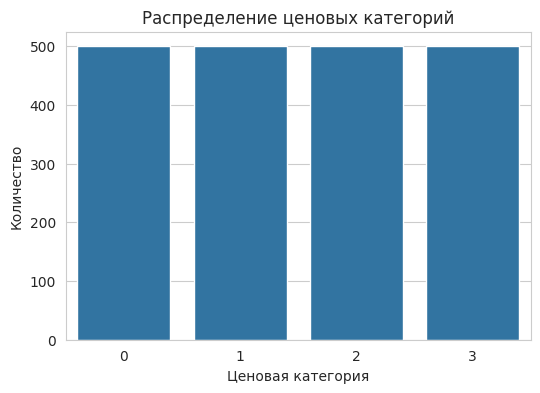

In [ ]:
# Визуализация
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='price_range')
plt.title('Распределение ценовых категорий')
plt.xlabel('Ценовая категория')
plt.savefig('price_range_distribution.png', dpi=150, bbox_inches='tight')
plt.ylabel('Количество')
plt.show()

# Корреляционный анализ
Наиболее сильно с ценой коррелируют ram (0.92), battery_power (0.20), px_height (0.15) и px_width (0.14).

In [ ]:
# Корреляция всех признаков с целевой переменной
corr = df.corr()['price_range'].sort_values(ascending=False)
print("Корреляция с ценовой категорией:")
print(corr)

Корреляция с ценовой категорией:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


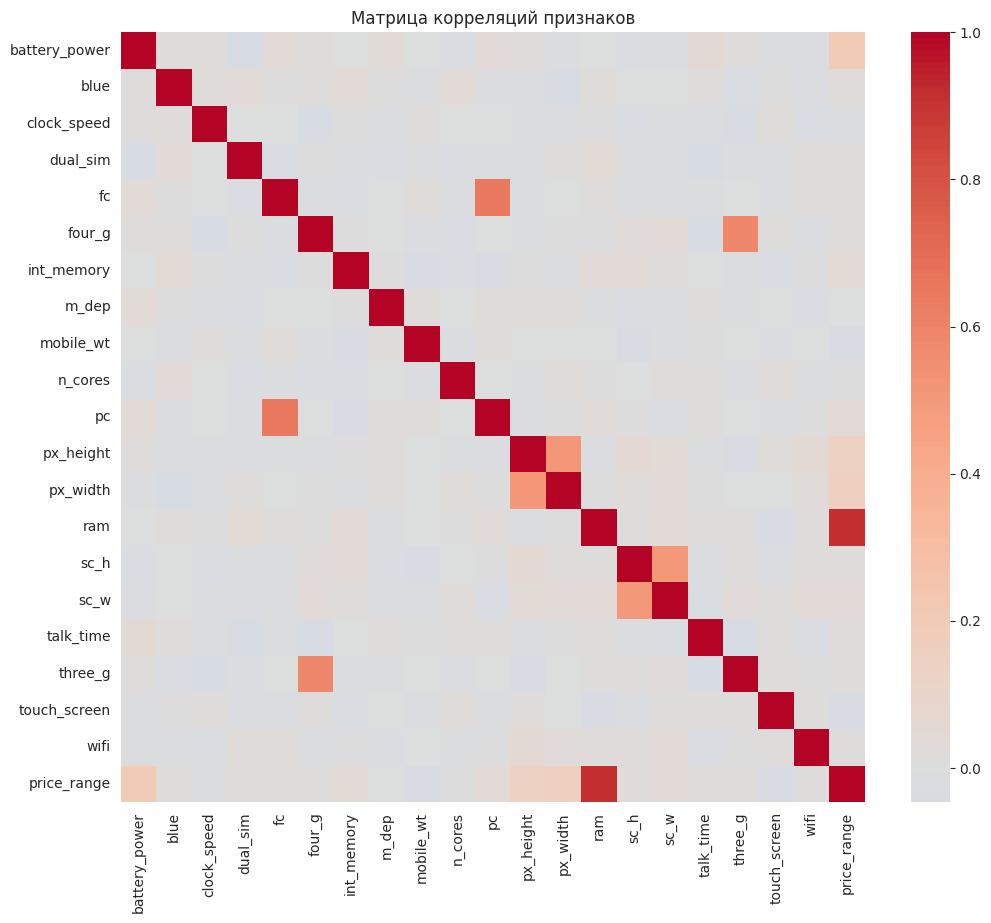

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Матрица корреляций признаков')
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Анализ распределений признаков
С ростом цены RAM значительно увеличивается. Батарея, разрешение экрана тоже в среднем выше у дорогих моделей.

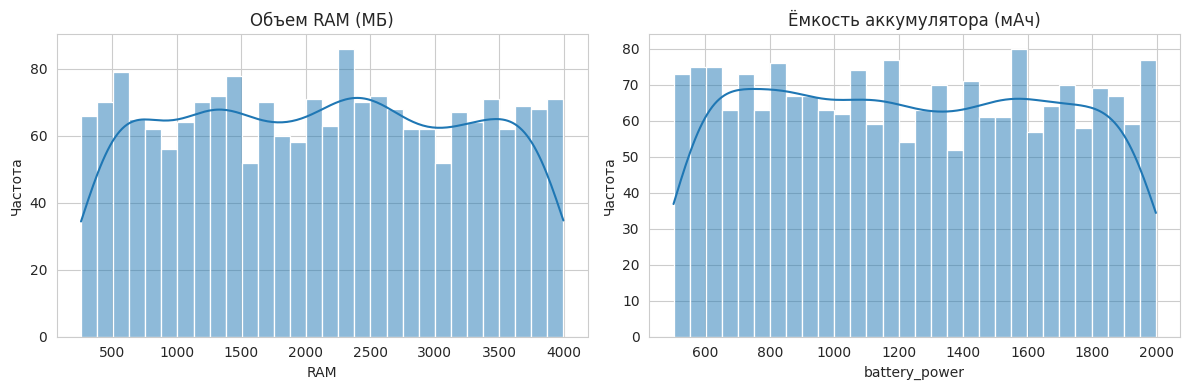

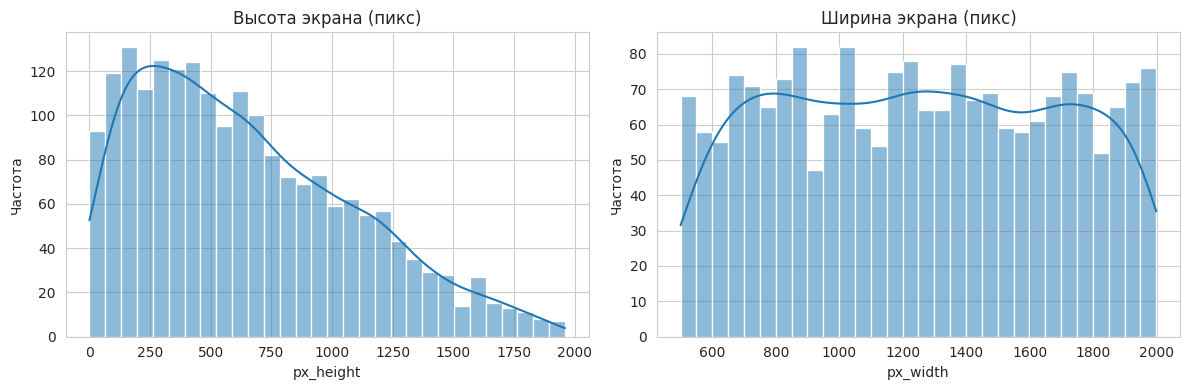

In [ ]:
# Первый график: ram и battery_power
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='ram', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Объем RAM (МБ)')
axes[0].set_xlabel('RAM')
axes[0].set_ylabel('Частота')

sns.histplot(data=df, x='battery_power', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Ёмкость аккумулятора (мАч)')
axes[1].set_xlabel('battery_power')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('hist_ram_battery.png', dpi=150, bbox_inches='tight')
plt.show()

# Второй график: px_height и px_width
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x='px_height', bins=30, kde=True, ax=axes[0])
axes[0].set_title('Высота экрана (пикс)')
axes[0].set_xlabel('px_height')
axes[0].set_ylabel('Частота')

sns.histplot(data=df, x='px_width', bins=30, kde=True, ax=axes[1])
axes[1].set_title('Ширина экрана (пикс)')
axes[1].set_xlabel('px_width')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.savefig('hist_px_height_width.png', dpi=150, bbox_inches='tight')
plt.show()

# Анализ бинарных признаков
Поддержка 4G и Wi-Fi значительно чаще встречается в дорогих моделях. Bluetooth, dual SIM, сенсорный экран распределены более равномерно.

In [ ]:
binary_cols = ['blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']
for col in binary_cols:
    print(f"\n{col}:")
    print(df.groupby('price_range')[col].value_counts(normalize=True).unstack())


blue:
blue             0      1
price_range              
0            0.514  0.486
1            0.510  0.490
2            0.514  0.486
3            0.482  0.518

dual_sim:
dual_sim         0      1
price_range              
0            0.500  0.500
1            0.490  0.510
2            0.502  0.498
3            0.470  0.530

four_g:
four_g           0      1
price_range              
0            0.482  0.518
1            0.476  0.524
2            0.506  0.494
3            0.450  0.550

three_g:
three_g          0      1
price_range              
0            0.254  0.746
1            0.244  0.756
2            0.226  0.774
3            0.230  0.770

touch_screen:
touch_screen      0      1
price_range               
0             0.476  0.524
1             0.478  0.522
2             0.530  0.470
3             0.504  0.496

wifi:
wifi             0      1
price_range              
0            0.504  0.496
1            0.496  0.504
2            0.496  0.504
3            0.476  0.524

# Проверка выбросов
Выбросы присутствуют, но их немного. Для деревьев они не страшны, для линейных моделей можно применить масштабирование.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('price_range')
outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_summary[col] = len(outliers)
print("Количество выбросов по признакам:")
print(pd.Series(outliers_summary).sort_values(ascending=False))

Количество выбросов по признакам:
three_g          477
fc                18
px_height          2
battery_power      0
dual_sim           0
clock_speed        0
blue               0
int_memory         0
m_dep              0
mobile_wt          0
n_cores            0
four_g             0
pc                 0
px_width           0
sc_h               0
ram                0
sc_w               0
talk_time          0
touch_screen       0
wifi               0
dtype: int64


# Выводы по EDA
1.Данные чистые, пропусков нет, классы сбалансированы.

2.Наиболее важный признак — ram (корреляция 0.92).

3.С ростом цены увеличиваются RAM, батарея, разрешение экрана, поддержка 4G и Wi-Fi.

4.Выбросы присутствуют, но не требуют обязательной обработки.

5.Для линейных моделей потребуется масштабирование признаков, для деревьев — нет.

# Выбор моделей и метрик
**Модели:**

Логистическая регрессия (baseline)

Случайный лес (Random Forest)

Градиентный бустинг (XGBoost)

**Метрики:**

Accuracy (общая точность)

Precision, Recall, F1-score (макро-усреднение, так как классы сбалансированы)

Confusion matrix (матрица ошибок)

In [26]:

# 1. Подготовка данных

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

X = df.drop('price_range', axis=1)
y = df['price_range']

if 'aspect_ratio' in X.columns:
    X = X.drop('aspect_ratio', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")
print(f"Распределение классов в train:\n{y_train.value_counts().sort_index()}")
print(f"Распределение классов в test:\n{y_test.value_counts().sort_index()}")

Размер обучающей выборки: 1600
Размер тестовой выборки: 400
Распределение классов в train:
price_range
0    400
1    400
2    400
3    400
Name: count, dtype: int64
Распределение классов в test:
price_range
0    100
1    100
2    100
3    100
Name: count, dtype: int64


In [37]:
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [52]:

# Логистическая регрессия

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

lr_baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
lr_baseline.fit(X_train, y_train)

y_pred_lr = lr_baseline.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr, rec_lr, f1_lr, _ = precision_recall_fscore_support(y_test, y_pred_lr, average='macro')

print("\n--- Логистическая регрессия  ---")
print(f"Accuracy: {acc_lr:.4f}")
print(f"Precision (macro): {prec_lr:.4f}")
print(f"Recall (macro): {rec_lr:.4f}")
print(f"F1 (macro): {f1_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


--- Логистическая регрессия  ---
Accuracy: 0.6825
Precision (macro): 0.6954
Recall (macro): 0.6825
F1 (macro): 0.6872
              precision    recall  f1-score   support

           0       0.91      0.86      0.88       100
           1       0.61      0.57      0.59       100
           2       0.49      0.59      0.54       100
           3       0.77      0.71      0.74       100

    accuracy                           0.68       400
   macro avg       0.70      0.68      0.69       400
weighted avg       0.70      0.68      0.69       400



In [40]:

# 4. Случайный лес

rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
                       rf_params, cv=5, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
print("Лучшие гиперпараметры RF:", rf_grid.best_params_)
print("Лучшая точность на кросс-валидации: {:.4f}".format(rf_grid.best_score_))

y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf, rec_rf, f1_rf, _ = precision_recall_fscore_support(y_test, y_pred_rf, average='macro')

print("\n--- Случайный лес на тесте ---")
print(f"Accuracy: {acc_rf:.4f}")
print(f"Precision (macro): {prec_rf:.4f}")
print(f"Recall (macro): {rec_rf:.4f}")
print(f"F1 (macro): {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

Лучшие гиперпараметры RF: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Лучшая точность на кросс-валидации: 0.8738

--- Случайный лес на тесте ---
Accuracy: 0.8925
Precision (macro): 0.8917
Recall (macro): 0.8925
F1 (macro): 0.8920
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       100
           1       0.84      0.83      0.83       100
           2       0.84      0.82      0.83       100
           3       0.95      0.95      0.95       100

    accuracy                           0.89       400
   macro avg       0.89      0.89      0.89       400
weighted avg       0.89      0.89      0.89       400



In [41]:

# 5. XGBoost

xgb_model = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss')

xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_
print("Лучшие гиперпараметры XGBoost:", xgb_grid.best_params_)
print("Лучшая точность на кросс-валидации: {:.4f}".format(xgb_grid.best_score_))

y_pred_xgb = best_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb, rec_xgb, f1_xgb, _ = precision_recall_fscore_support(y_test, y_pred_xgb, average='macro')

print("\n--- XGBoost на тесте ---")
print(f"Accuracy: {acc_xgb:.4f}")
print(f"Precision (macro): {prec_xgb:.4f}")
print(f"Recall (macro): {rec_xgb:.4f}")
print(f"F1 (macro): {f1_xgb:.4f}")
print(classification_report(y_test, y_pred_xgb))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Лучшие гиперпараметры XGBoost: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Лучшая точность на кросс-валидации: 0.9087

--- XGBoost на тесте ---
Accuracy: 0.9350
Precision (macro): 0.9347
Recall (macro): 0.9350
F1 (macro): 0.9348
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       100
           1       0.94      0.92      0.93       100
           2       0.90      0.89      0.89       100
           3       0.94      0.94      0.94       100

    accuracy                           0.94       400
   macro avg       0.93      0.94      0.93       400
weighted avg       0.93      0.94      0.93       400



                 Model  Accuracy  Precision (macro)  Recall (macro)  \
0  Logistic Regression    0.6825           0.695393          0.6825   
1        Random Forest    0.8925           0.891717          0.8925   
2              XGBoost    0.9350           0.934733          0.9350   

   F1 (macro)  
0    0.687168  
1    0.892030  
2    0.934784  


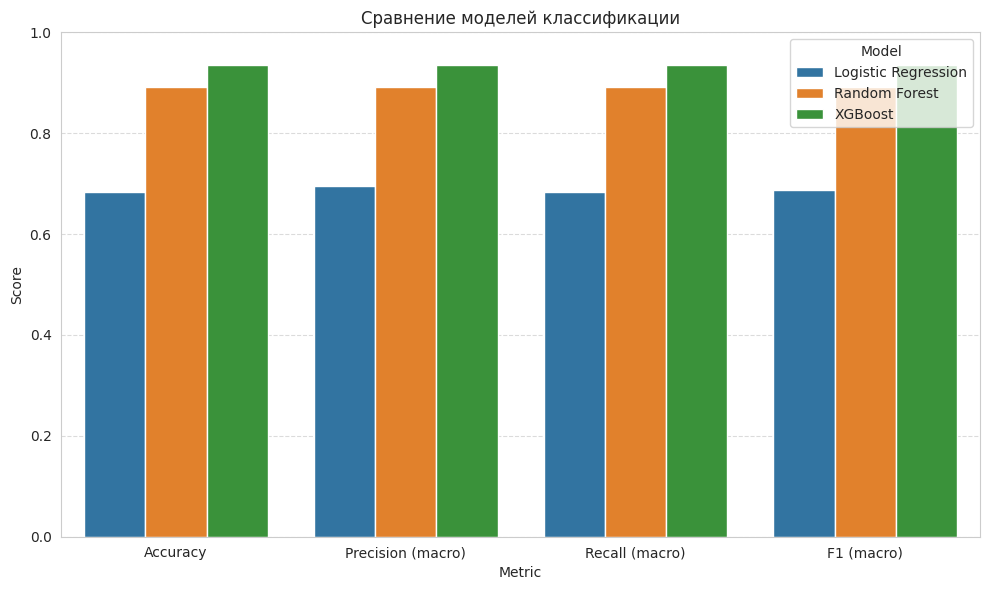

In [42]:

# 6. Сравнение моделей

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb],
    'Precision (macro)': [prec_lr, prec_rf, prec_xgb],
    'Recall (macro)': [rec_lr, rec_rf, rec_xgb],
    'F1 (macro)': [f1_lr, f1_rf, f1_xgb]
})
print(results)

fig, ax = plt.subplots(figsize=(10, 6))
results_melted = results.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Metric', y='Score', hue='Model', ax=ax)
ax.set_title('Сравнение моделей классификации')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

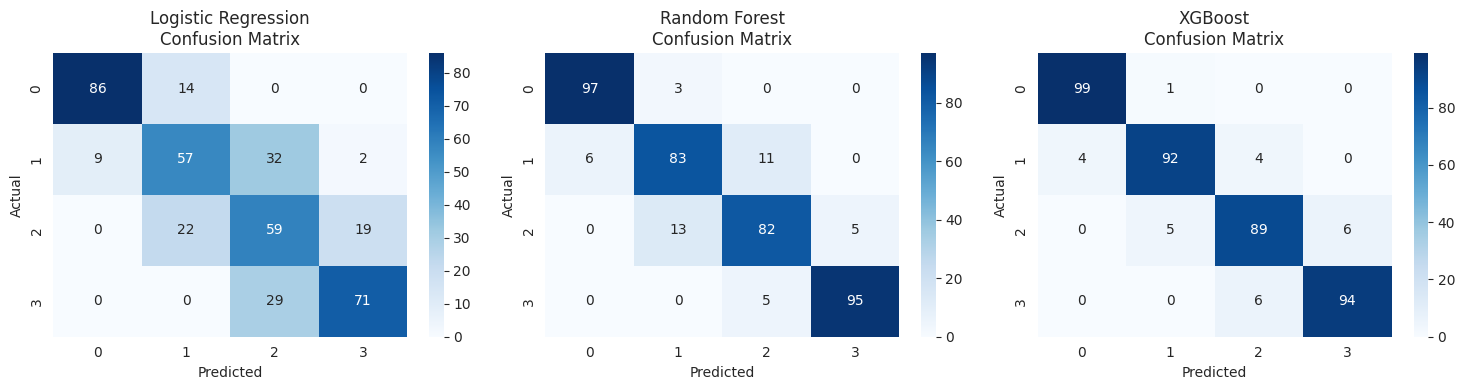

In [49]:
# 7. Матрицы ошибок

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
models = [lr_baseline, best_rf, best_xgb]   # используем лучшие модели после GridSearch
names = ['Logistic Regression', 'Random Forest', 'XGBoost']

for i, (model, name) in enumerate(zip(models, names)):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=[0,1,2,3], yticklabels=[0,1,2,3])
    axes[i].set_title(f'{name}\nConfusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

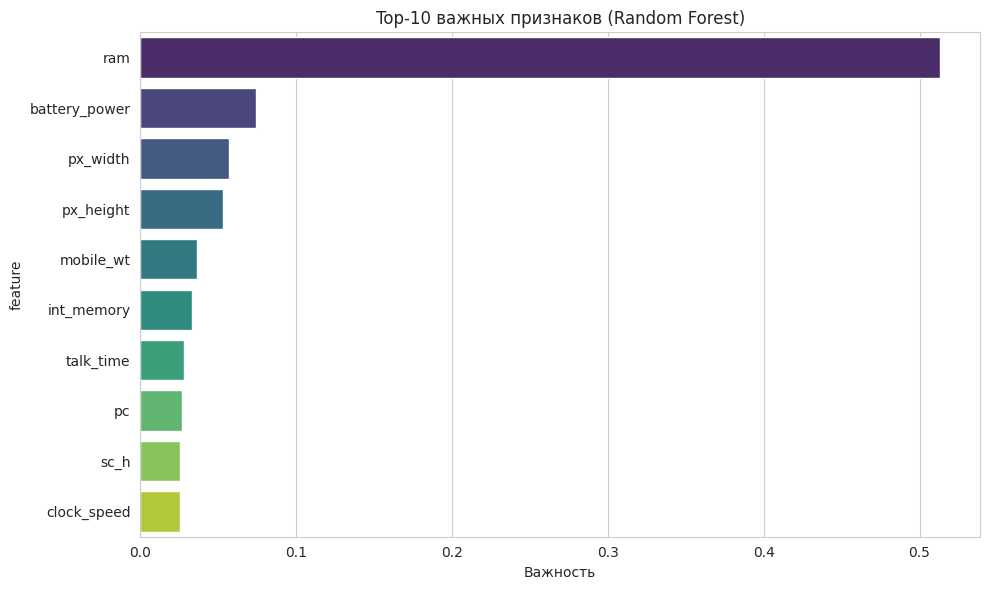

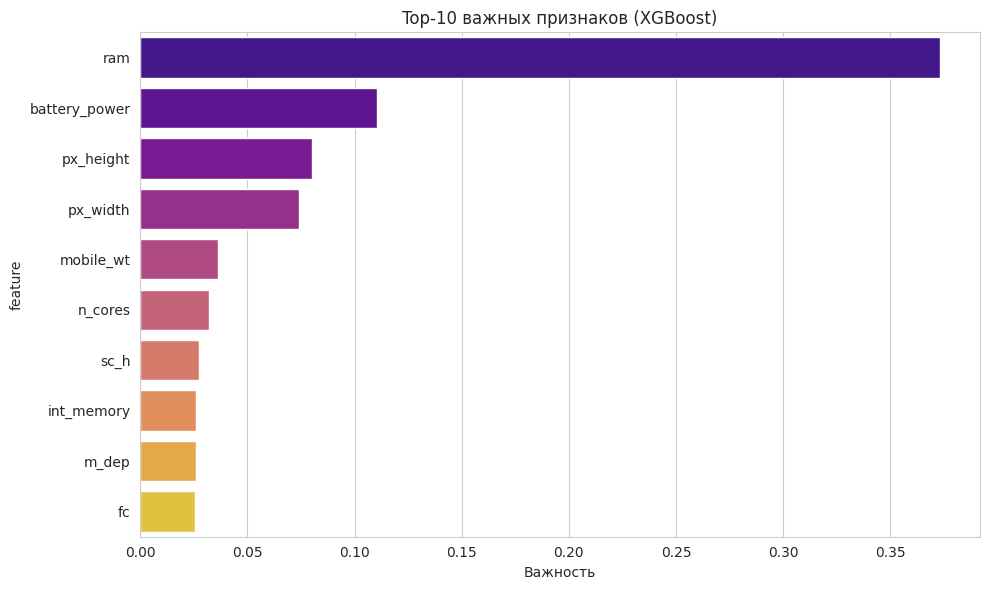

In [50]:
# Вычисление важности признаков
feature_imp_rf = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_imp_xgb = pd.DataFrame({
    'feature': X.columns,
    'importance': best_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Random Forest
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_rf.head(10), x='importance', y='feature',
            hue='feature', palette='viridis', legend=False)
plt.title('Top-10 важных признаков (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

# XGBoost
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_xgb.head(10), x='importance', y='feature',
            hue='feature', palette='plasma', legend=False)
plt.title('Top-10 важных признаков (XGBoost)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:

# 9. Итоговые выводы

print("Итоги моделирования:")
print(f"Лучшая модель по Accuracy: {results.loc[results['Accuracy'].idxmax(), 'Model']} "
      f"с Accuracy = {results['Accuracy'].max():.4f}")
print(f"Лучшая модель по F1 (macro): {results.loc[results['F1 (macro)'].idxmax(), 'Model']} "
      f"с F1 = {results['F1 (macro)'].max():.4f}")
print("\nРекомендации:")
print("- XGBoost и Random Forest показали высокое качество (Accuracy ~0.90+).")
print("- Логистическая регрессия значительно слабее из-за нелинейных зависимостей.")
print("- Основные драйверы цены: RAM, battery_power, разрешение экрана, поддержка 4G/WiFi.")
print("- Признак ram имеет решающее значение – корреляция 0.92.")

Итоги моделирования:
Лучшая модель по Accuracy: XGBoost с Accuracy = 0.9350
Лучшая модель по F1 (macro): XGBoost с F1 = 0.9348

Рекомендации:
- XGBoost и Random Forest показали высокое качество (Accuracy ~0.90+).
- Логистическая регрессия значительно слабее из-за нелинейных зависимостей.
- Основные драйверы цены: RAM, battery_power, разрешение экрана, поддержка 4G/WiFi.
- Признак ram имеет решающее значение – корреляция 0.92.
